In [2]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
#==========setup .env ===========
if os.getenv("GEMINI_API_KEY") is None:
    raise ValueError("GEMINI_API_KEY environment variable not set. Please set it in your .env file.")
else:
    print("GEMINI_API_KEY environment variable is set.")

GEMINI_API_KEY environment variable is set.


In [3]:

model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite",
                                max_tokens=2048,temperature=0.5,
                                 api_key=os.getenv("GEMINI_API_KEY"))

In [4]:

response = model.invoke("how does transformer work in brief?")
print(response.content[0]["text"])

At its simplest, a Transformer is a machine learning model designed to process sequences of data (like sentences) by looking at the **entire sequence at once**, rather than one word at a time.

Here is the brief breakdown of how it works:

### 1. Input: Embeddings and Positional Encoding
*   **Embeddings:** Computers don’t understand words, so the Transformer converts each word into a list of numbers (a vector) that represents its meaning.
*   **Positional Encoding:** Because the Transformer processes all words simultaneously, it doesn't naturally know the order of the sentence. It adds a "timestamp" to each word vector so the model knows that "dog bites man" is different from "man bites dog."

### 2. The Core: The "Attention" Mechanism
This is the "secret sauce" of the Transformer. It allows the model to determine how much focus to put on other words in the sentence when processing a specific word.
*   **Example:** In the sentence *"The animal didn't cross the street because **it** wa

In [ ]:
from typing import TypedDict

#1- define the schema of the graph
class graph_schema(TypedDict):
    name: str
    user_message: str
    llm_message: str

def welcome_message(state:graph_schema) -> graph_schema:
    name=state["name"]
    current_message=state["user_message"]

    response = model.invoke(f"you are helpfull assistance the user name is {name} respond to the following user message and be friendly: {current_message}")
    llm_message=response.content[0]["text"]
    state["llm_message"]=llm_message
    return state

state=graph_schema(name="Alice",user_message="how are you today ?", llm_message="")
history=welcome_message(state)
history

{'name': 'Alice',
 'user_message': 'how are you today ?',
 'llm_message': "Hello Alice! I'm doing wonderful, thank you so much for asking. How are you doing today? Is there anything I can help you with?"}

In [6]:
from langgraph.graph import StateGraph,START,END

graph=StateGraph(graph_schema)

graph.add_node("welcome_message",welcome_message)
graph.add_edge(START,"welcome_message")
graph.add_edge("welcome_message",END)


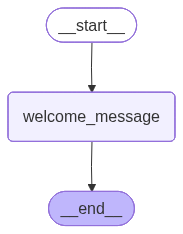

In [7]:
from IPython.display import Image,display

firts_graph=graph.compile()

display(Image(firts_graph.get_graph().draw_mermaid_png()))

In [8]:
print(firts_graph.get_graph().draw_mermaid())
# then use mermaid live editor to visualize the graph

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	welcome_message(welcome_message)
	__end__([<p>__end__</p>]):::last
	__start__ --> welcome_message;
	welcome_message --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [9]:
# run the graph
firts_graph.invoke(state)

{'name': 'Alice',
 'user_message': 'how are you today ?',
 'llm_message': "Hello Alice! I'm doing wonderful, thank you so much for asking. It's a pleasure to assist you today. How are things going with you?"}